# Automação de Superfície e Coleta de Dados no Inn Tycoon

## O Contexto do Desafio e a Visão Arquitetural

O que eu queria fazer era explorar o *Inn Tycoon Prologue*, um jogo de simulação de negócios onde você gerencia uma taverna, vende cervejas e refeições, contrata funcionários e lida com o fluxo de caixa. Através desse jogo, eu vi um ótimo ecossistema para fazer coleta de dados. A ideia seria extrair os dados brutos de progresso do jogo com o decorrer do tempo e ir armazenando tudo em um CSV para, posteriormente, fazer análises e otimizar os custos e ganhos baseados na economia da taverna.

Infelizmente, muitos jogos não exportam esses dados de forma nativa. Mas ao realizar esse projeto, eu quis demonstrar que poderíamos criar micro cenários de *Data Science* para democratizar o aprendizado, permitindo que as pessoas se familiarizem com o processo criando seus próprios pipelines de dados a partir de suas gameplays. 

Para extrair isso, eu decidi usar visão computacional. E foi aqui que a base teórica sobre automação se provou extremamente útil, me ajudando a mapear a arquitetura da minha solução:

> **Reflexão Técnica 1:** *Qual característica define a arquitetura básica do meu script, já que não uso APIs oficiais do jogo?*
> A resposta é a **interação na camada de interface do usuário**. A automação que estou construindo "senta na cadeira" e usa a tela visualmente, imitando o jogador.

> **Reflexão Técnica 2:** *E se esse meu processo falhar miseravelmente após uma atualização do sistema do jogo, qual seria a explicação técnica mais adequada?*
> É uma **característica inerente à operação na camada de apresentação**. Como não opero no *backend* ou em bancos de dados, qualquer mudança visual afeta diretamente o meu script.

## Governança de Ambiente e Estabilidade do Script

Para o setup, o meu laptop estava conectado a outras quatro telas. O jogo ficaria aberto em um monitor específico de 32 polegadas. 

<img src="../docs/assets/system_display.png" alt="System Display">
<img src="../docs/assets/scale_and_layout.png" alt="Scale and Layout">
<img src="../docs/assets/main_display.png" alt="Main Display">

Definir esse ambiente com precisão foi crucial. Eu precisei ir nas configurações do Windows, setar essa tela 4 como "Make this my main display" e travar a resolução em 4K (3840x2160). Esse rigor nas configurações resolve o meu maior problema operacional:

> **Reflexão Técnica 3:** *Qual é a limitação crítica dessa minha automação (RPA) que justifica eu fixar o hardware dessa forma?*
> A limitação é que **alterações na interface gráfica podem quebrar os fluxos automatizados do RPA, o que exige reconfiguração**. Se o jogo mudar de monitor ou a escala do Windows alterar, meu código tentará "ler" o vazio. Portanto, fixar a resolução do display foi a minha governança de ambiente para garantir a estabilidade do processo.

## Simulação e Geração de Dados Brutos (Raw Data)

Antes de capturar a tela real, pensei matematicamente. Eu não precisava processar a tela inteira, apenas regiões específicas (Zonas de Interesse ou ROIs). Criei um ambiente de simulação: gerei uma imagem em branco com as exatas dimensões da tela 4K e tracejei linhas vermelhas no centro para me guiar. 

Como estou gerando essas imagens via script para usar como gabarito, elas são literalmente meus dados brutos de simulação, salvos na pasta relativa `../data/raw`.

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Definindo caminhos relativos do projeto
RAW_DATA_DIR = r"../data/raw"

# Garantir que a pasta raw exista
os.makedirs(RAW_DATA_DIR, exist_ok=True)

# Dimensões da imagem (Monitor 4K)
width, height = 3840, 2160

# 1. Criar uma imagem branca (Dado bruto simulado)
white_image = Image.new("RGB", (width, height), "white")
path_white_image = os.path.join(RAW_DATA_DIR, "white_image.png")
white_image.save(path_white_image)

# 2. Desenhar linhas vermelhas no centro da imagem para mapeamento matemático
white_image_with_lines = white_image.copy()
draw = ImageDraw.Draw(white_image_with_lines)

# Coordenadas das linhas centrais
center_x = width // 2
center_y = height // 2

# Desenhar linha vertical e horizontal (vermelhas)
draw.line([(center_x, 0), (center_x, height)], fill="red", width=5)
draw.line([(0, center_y), (width, center_y)], fill="red", width=5)

# Salvar a imagem com as linhas
path_white_lines = os.path.join(RAW_DATA_DIR, "white_image_with_lines.png")
white_image_with_lines.save(path_white_lines)

print(f"Dados brutos de simulação gerados com sucesso em:\n{os.path.abspath(RAW_DATA_DIR)}")

Dados brutos de simulação gerados com sucesso em:
c:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\phrases\01\chapters\02\inn_tycoon_prologue\data\raw


## Isolamento de Dependências e a Escolha Arquitetural

Para codificar esse script e gerar as imagens acima, precisei de bibliotecas como `OpenCV` e `Pillow`. Ao isolar isso em um ambiente virtual (`venv`), validei a seguinte afirmação da teoria:

> **Reflexão Técnica 4:** *Como a minha máquina suporta criar ambientes virtuais isolados sem duplicar completamente o interpretador Python e esgotar o meu HD?*
> A afirmação correta é que os ambientes virtuais **utilizam mecanismos de otimização de espaço**. Eles criam links simbólicos inteligentes em vez de cópias físicas.

Além disso, eu escolhi escrever tudo na raça com código Python, tomando uma decisão consciente sobre a arquitetura da solução:

> **Reflexão Técnica 5:** *Eu desenvolvi tudo na unha. Na implementação da minha solução, ferramentas de 'arrastar e soltar' seriam obrigatórias?*
> Não. Os **ambientes de desenvolvimento low-code** são componentes que podem ser considerados complementares, porém, não obrigatórios. Eles democratizam a criação, mas a espinha dorsal lógica continua sendo algorítmica.

## Validação Matemática das Zonas de Interesse (ROIs)

Baseado nas linhas imaginárias que tracejei, consegui identificar as zonas de interesse (ROIs) onde o jogo apresenta as estatísticas. A ideia era criar um script que, a cada intervalo de tempo, abrisse essa interface e verificasse as mudanças. E aqui entra o conceito central do BPM:

> **Reflexão Técnica 6:** *Para garantir que a coleta desses dados realmente sustente a minha iniciativa de entender a economia da taverna ao longo do tempo, qual etapa é fundamental?*
> O **monitoramento contínuo e a análise de desempenho**. Sem aplicar as análises sobre o CSV, eu só estaria entupindo meu HD com prints aleatórios sem gerar valor preditivo pro negócio.

Vamos testar o mascaramento (pintando de preto as áreas de interesse) em cima da nossa imagem de simulação para validar a matemática dos pixels.

Dimensões do Canvas: 3840x2160 | Canais: 3


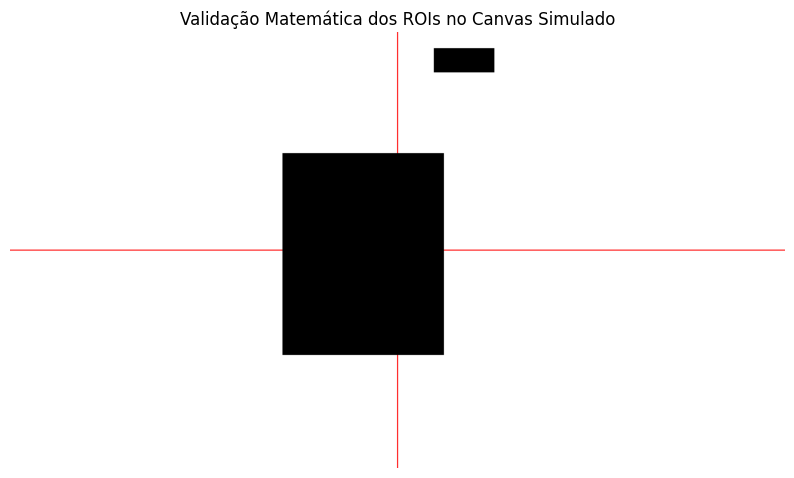

In [2]:
# Carregar o canvas de simulação gerado na etapa anterior
caminho_imagem_simulacao = path_white_lines
img_simulacao = cv2.imread(caminho_imagem_simulacao, cv2.IMREAD_COLOR)

if img_simulacao is None:
    raise FileNotFoundError(f"Imagem não encontrada em: {caminho_imagem_simulacao}")

altura, largura, canais = img_simulacao.shape
print(f"Dimensões do Canvas: {largura}x{altura} | Canais: {canais}")

# ROI 1: Área de dinheiro/status do topo (Coordenadas Matemáticas)
padding_top_1 = 80
padding_left_1 = 2100
ret_altura_1 = 120
ret_largura_1 = 300
img_simulacao[padding_top_1:padding_top_1 + ret_altura_1, padding_left_1:padding_left_1 + ret_largura_1] = [0, 0, 0]

# ROI 2: Área do painel principal de estatísticas (Coordenadas Matemáticas)
padding_top_2 = 600
padding_left_2 = 1350
ret_altura_2 = 1000
ret_largura_2 = 800
img_simulacao[padding_top_2:padding_top_2 + ret_altura_2, padding_left_2:padding_left_2 + ret_largura_2] = [0, 0, 0]

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_simulacao, cv2.COLOR_BGR2RGB))
plt.title("Validação Matemática dos ROIs no Canvas Simulado")
plt.axis("off")
plt.show()

## Aplicação na Interface Real e a Evolução para Hiperautomação

Com a matemática validada no ambiente em branco, chegou a hora de plugar a imagem real do jogo para provar a tese. 

<img src="../docs/assets/game_interface_view.png" alt="Game Interface View">

Para fechar o raciocínio estratégico: o que construí até aqui é uma Automação de Superfície. Pensando no futuro da minha taverna, a última reflexão teórica define exatamente o meu próximo alvo:

> **Reflexão Técnica 7:** *Em um projeto de automação focado na minha gestão de recursos do jogo, qual combinação representaria melhor uma solução real de hiperautomação?*
> A união da **automação de tarefas, análise inteligente e gestão de fluxos**. Se amanhã eu integrar a extração de texto dessas áreas pretas (Automação de Tarefas) com um modelo preditivo (Análise Inteligente), e usar isso para engatilhar um bot que compra automaticamente mais cerveja quando o estoque for acabar (Gestão de Fluxos), eu terei atingido a Hiperautomação no nível mais avançado.

Aqui está o teste final do mapeamento aplicado diretamente na interface real do jogo.

Dimensões Originais do Print: 3839x2158
Nova dimensão padronizada: 3840x2160


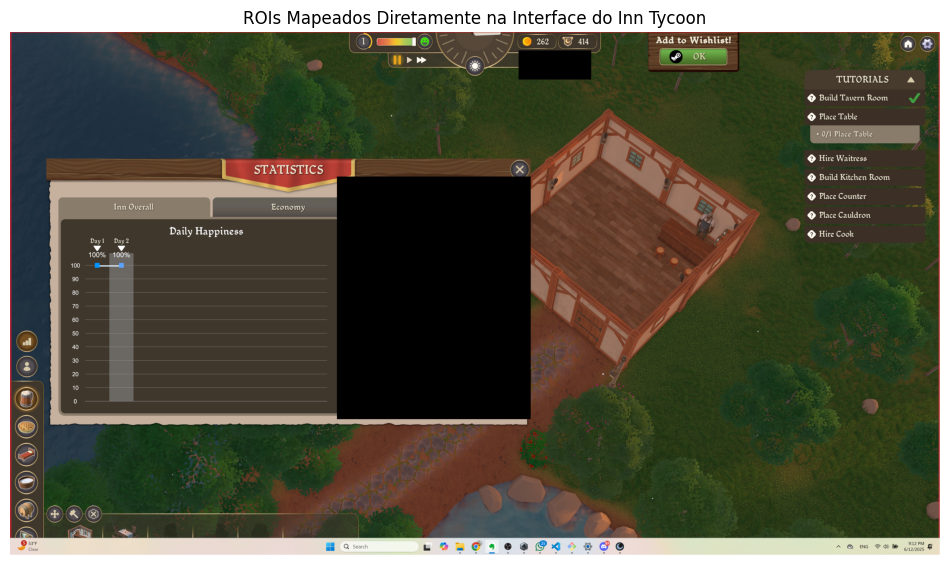

In [3]:
# Caminho relativo do print real do jogo salvo nos docs/assets
caminho_game_view = r"../docs/assets/game_interface_view.png"

# Carregar a imagem real
img_game = cv2.imread(caminho_game_view)

if img_game is None:
    raise FileNotFoundError(f"Imagem não encontrada em: {caminho_game_view}")

# Obter dimensões originais do print
altura_g, largura_g, canais_g = img_game.shape
print(f"Dimensões Originais do Print: {largura_g}x{altura_g}")

# Garantir que a imagem tenha 3840x2160 (Preenchendo bordas se necessário para não quebrar a automação)
delta_w = 3840 - largura_g
delta_h = 2160 - altura_g

top = delta_h // 2
bottom = delta_h - top
left = delta_w // 2
right = delta_w - left

img_expandida = cv2.copyMakeBorder(
    img_game, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[255, 255, 255]
)

print(f"Nova dimensão padronizada: {img_expandida.shape[1]}x{img_expandida.shape[0]}")

# Aplicando as Máscaras (ROIs) na imagem real baseada nas coordenadas definidas
img_expandida[padding_top_1:padding_top_1 + ret_altura_1, padding_left_1:padding_left_1 + ret_largura_1] = [0, 0, 0]
img_expandida[padding_top_2:padding_top_2 + ret_altura_2, padding_left_2:padding_left_2 + ret_largura_2] = [0, 0, 0]

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(img_expandida, cv2.COLOR_BGR2RGB))
plt.title("ROIs Mapeados Diretamente na Interface do Inn Tycoon")
plt.axis("off")
plt.show()